# Installing required Libraries 
    -> pandas
    -> seaborn (matplotlib)
    -> numpy
    

In [1]:
!pip install pandas

In [2]:
!pip install numpy 
!pip install seaborn

# Steps to be done 
- Read CSV
- Check for null values 
- Plot relations between variables
- Design model



In [3]:
import seaborn as sb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd #import pandas to read csv and handle the data
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [4]:
df = pd.read_csv("water_data.csv") # GroundWater sample training data set

In [5]:
df.head()

,tank_capacity,current_level,residents,daily_usage,rainfall,season,days_left
0,10700,1018,36,4307.298198,6.478662,winter,0.24
1,12672,9100,50,6724.696205,7.484769,summer,1.35
2,8618,3725,19,2928.959925,7.045614,winter,1.27
3,5613,2537,24,3461.914197,8.365875,summer,0.73
4,12041,8849,28,3528.505924,6.299878,summer,2.51


In [6]:
df.describe()

,tank_capacity,current_level,residents,daily_usage,rainfall,days_left
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,12713.965000,7005.641000,27.976000,3881.624207,5.147733,2.807900
std,4318.504797,4248.320807,13.533535,2038.642050,2.879322,3.402469
min,5048.000000,1015.000000,5.000000,467.548211,0.000144,0.130000
25%,9070.000000,3714.500000,16.000000,2203.924990,2.725214,0.900000
50%,12866.000000,6033.000000,28.000000,3740.123715,5.339205,1.705000
75%,16517.750000,9883.000000,40.000000,5389.828872,7.625616,3.220000
max,19957.000000,19366.000000,50.000000,9869.820252,9.997389,29.160000


## Checking for NULL values

In [7]:
df["tank_fill_ratio"] = df["current_level"] / df["tank_capacity"]
df["usage_per_person"] = df["daily_usage"] / df["residents"]

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   tank_capacity     1000 non-null   int64  
 1   current_level     1000 non-null   int64  
 2   residents         1000 non-null   int64  
 3   daily_usage       1000 non-null   float64
 4   rainfall          1000 non-null   float64
 5   season            1000 non-null   str    
 6   days_left         1000 non-null   float64
 7   tank_fill_ratio   1000 non-null   float64
 8   usage_per_person  1000 non-null   float64
dtypes: float64(5), int64(3), str(1)
memory usage: 70.4 KB


### No null values are present, therefore continuing to find relationship 

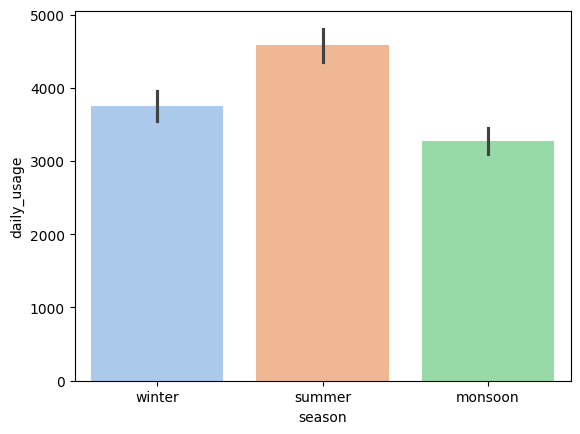

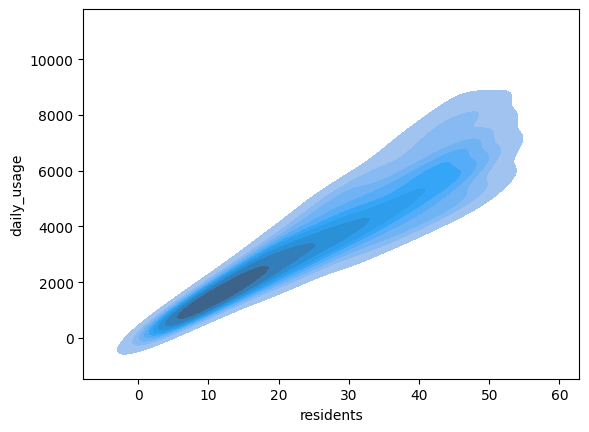

In [9]:
plt.figure()
sb.barplot(df,y='daily_usage',x='season',palette="pastel",capsize=None)
plt.show()

plt.figure()
sb.kdeplot(data=df, x='residents',y='daily_usage', fill=True)
plt.show()

<Axes: >

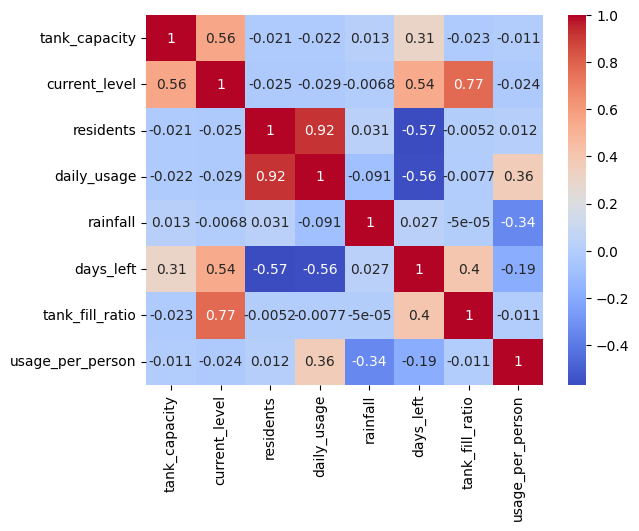

In [10]:
corr = df.corr(numeric_only=True)
sb.heatmap(corr, annot=True, cmap='coolwarm')

## From the above observations we can infer that 
* Season affect daily usage
* Residents and daily_usage are +ve highly correlated
* Residents and daily usage are -ve correlated

In [11]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


## Tying with Several regression model
* Elastic Net
* RandomForest Regressor

In [12]:
from sklearn.datasets import make_regression
from sklearn.linear_model import Ridge

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split 
#splits data into training data(to learn) and testing data(to check performance of model)

from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
#A simple ML model

In [13]:
X = df[[
    "tank_capacity",
    "current_level",
    "residents",
    "daily_usage",
    "rainfall",
    "tank_fill_ratio",
    "usage_per_person"
]]

In [14]:
y = df["days_left"] #What needs to be predicted (Answer the model should give for the question)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Create pipeline (VERY IMPORTANT)
model = ElasticNet(alpha=0.1, l1_ratio=0.2)
# 5. Train
model.fit(X_train, y_train)

# 6. Evaluate
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

scores = cross_val_score(model, X_train, y_train, cv=5)
print(scores)
print(scores.mean())

MAE: 1.4088359561912325
R2 Score: 0.646866398825451
[0.65732878 0.62758025 0.69546657 0.56492568 0.67813769]
0.6446877943110157


In [16]:
#TRAIN MODEL
model = RandomForestRegressor() # Creates an empty ML model (not trained yet)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

scores = cross_val_score(model, X_train, y_train, cv=5)
print(scores)
print(scores.mean())

MAE: 0.24221799999999993
R2 Score: 0.9672020943313079
[0.95910549 0.9678453  0.97785355 0.9454199  0.97362323]
0.964769493656082


## From the above experiment ... 
Elastic Net performs better than random forest regresor
$$ 
Elastic mean = 0.644
$$
$$
Random Forest Regressor mean = 0.96
$$

In [18]:
model.fit(X, y)
y_pred = model.predict(X)

In [19]:
print(X[:5])
print(X.mean(), X.std())

   tank_capacity  current_level  residents  daily_usage  rainfall  \
0          10700           1018         36  4307.298198  6.478662   
1          12672           9100         50  6724.696205  7.484769   
2           8618           3725         19  2928.959925  7.045614   
3           5613           2537         24  3461.914197  8.365875   
4          12041           8849         28  3528.505924  6.299878   

   tank_fill_ratio  usage_per_person  
0         0.095140        119.647172  
1         0.718119        134.493924  
2         0.432235        154.155786  
3         0.451986        144.246425  
4         0.734906        126.018069  
tank_capacity       12713.965000
current_level        7005.641000
residents              27.976000
daily_usage          3881.624207
rainfall                5.147733
tank_fill_ratio         0.553018
usage_per_person      138.604858
dtype: float64 tank_capacity       4318.504797
current_level       4248.320807
residents             13.533535
daily_usa

In [20]:
import pickle   # Saves the trained model into a file

pickle.dump(model, open("model.pkl", "wb"))